In [38]:
# Standard libraries
import os
import shutil

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory, image
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Transfer learning (ResNet)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
#import os
#import shutil
#import pandas as pd

base_dir = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\Distracted Driver Detection.v1i.multiclass"
output_dir = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean"

splits = ["train", "valid", "test"]

final_classes = [
    "drinking",
    "hair and makeup",
    "operating the radio",
    "reaching behind",
    "safe driving",
    "talking on the phone - left",
    "talking on the phone - right",
    "talking to passenger",
    "texting - left",
    "texting - right"
]

for split in splits:
    print(f"\nProcessing {split}...")

    split_dir = os.path.join(base_dir, split)
    csv_path = os.path.join(split_dir, "_classes.csv")
    clean_split_dir = os.path.join(output_dir, split)

    os.makedirs(clean_split_dir, exist_ok=True)

    df = pd.read_csv(csv_path)

    for _, row in df.iterrows():
        filename = row["filename"]

        active_labels = [col for col in final_classes if col in df.columns and row[col] == 1]

        if len(active_labels) == 0:
            continue

        label = active_labels[0].strip().lower()

        src = os.path.join(split_dir, filename)
        dst_dir = os.path.join(clean_split_dir, label)
        os.makedirs(dst_dir, exist_ok=True)

        if os.path.exists(src):
            shutil.copy2(src, os.path.join(dst_dir, filename))
        else:
            print(f"Missing image: {src}")

print("\nClean dataset created successfully.")


Processing train...

Processing valid...

Processing test...

Clean dataset created successfully.


In [39]:
#import tensorflow as tf
#from tensorflow.keras.preprocessing import image_dataset_from_directory

data_dir = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean"

train_data = image_dataset_from_directory(
    data_dir + r"\train",
    image_size=(224, 224),
    batch_size=32
)

val_data = image_dataset_from_directory(
    data_dir + r"\valid",
    image_size=(224, 224),
    batch_size=32
)

test_data = image_dataset_from_directory(
    data_dir + r"\test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print("Classes:", train_data.class_names)

Found 1875 files belonging to 10 classes.
Found 201 files belonging to 10 classes.
Found 112 files belonging to 10 classes.
Classes: ['drinking', 'hair and makeup', 'operating the radio', 'reaching behind', 'safe driving', 'talking on the phone - left', 'talking on the phone - right', 'talking to passenger', 'texting - left', 'texting - right']


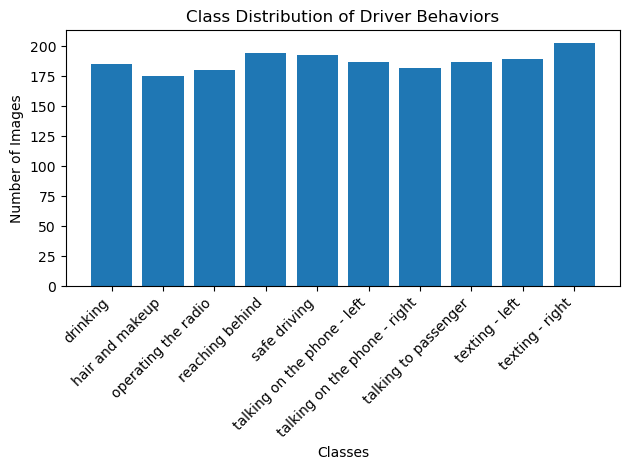

In [40]:
#import os
#import matplotlib.pyplot as plt

# path to training dataset
data_dir = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean\train"

class_names = []
class_counts = []

# count images in each class folder
for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_names.append(class_name)
        class_counts.append(count)

# plot
plt.figure()
plt.bar(class_names, class_counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Driver Behaviors")
plt.tight_layout()
plt.show()

In [5]:
#import tensorflow as tf
#from tensorflow.keras import layers, models



In [41]:
#model

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
#Early stopping to prevent overfit

#from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)
#Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=[early_stop, lr_scheduler]
)


#evaluate
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

#save the model
model.save("baseline_cnn_driver_distraction.keras")

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1168 - loss: 2.3849 - val_accuracy: 0.1393 - val_loss: 2.2709 - learning_rate: 0.0010
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.3035 - loss: 2.0320 - val_accuracy: 0.4826 - val_loss: 1.6325 - learning_rate: 0.0010
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.6400 - loss: 1.0922 - val_accuracy: 0.6766 - val_loss: 1.1596 - learning_rate: 0.0010
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8011 - loss: 0.6015 - val_accuracy: 0.7711 - val_loss: 0.9049 - learning_rate: 0.0010
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8987 - loss: 0.3129 - val_accuracy: 0.7960 - val_loss: 0.9012 - learning_rate: 0.0010
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9280 - loss: 0.2197 - val_accuracy: 0.8159 - val_loss: 0.8729 - learning_rate: 0.0010
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9483 - loss: 0.1595 - val_accuracy: 

In [43]:
model.save(r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\baseline_cnn_driver_distraction.keras")

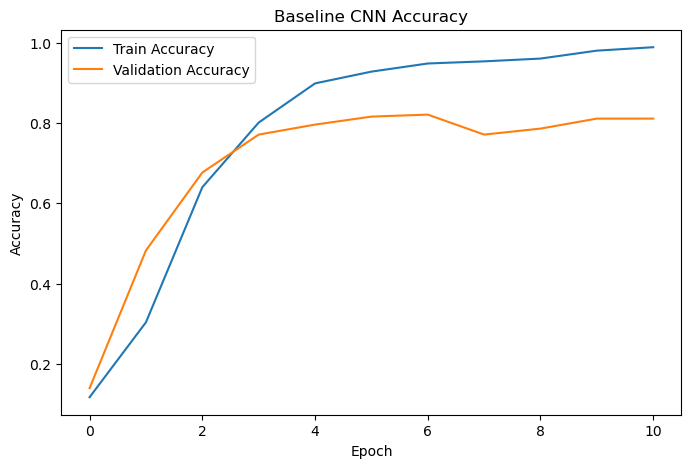

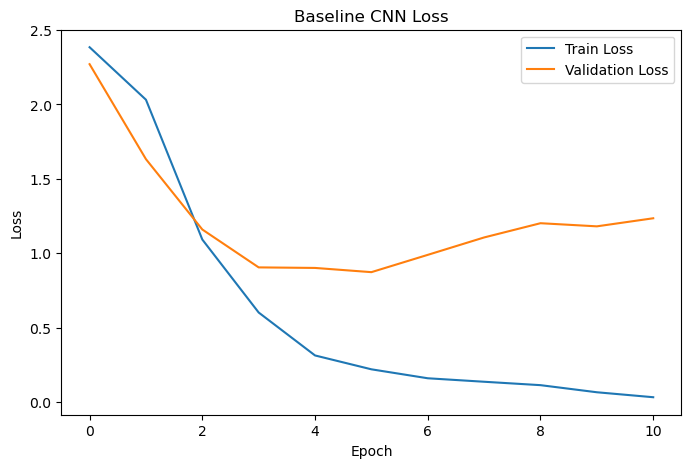

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Baseline CNN Accuracy')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Baseline CNN Loss')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 350ms/step
                              precision    recall  f1-score   support

                    drinking       0.91      0.83      0.87        12
             hair and makeup       0.67      0.73      0.70        11
         operating the radio       0.90      0.90      0.90        10
             reaching behind       1.00      0.90      0.95        10
                safe driving       0.83      0.83      0.83         6
 talking on the phone - left       1.00      0.92      0.96        12
talking on the phone - right       0.88      0.88      0.88        16
        talking to passenger       0.73      0.73      0.73        11
              texting - left       0.87      1.00      0.93        13
             texting - right       1.00      1.00      1.00        11

                    accuracy                           0.88       112
                   macro avg       0.88      0.87      0.87       112
                weighted avg       0.88      0.88

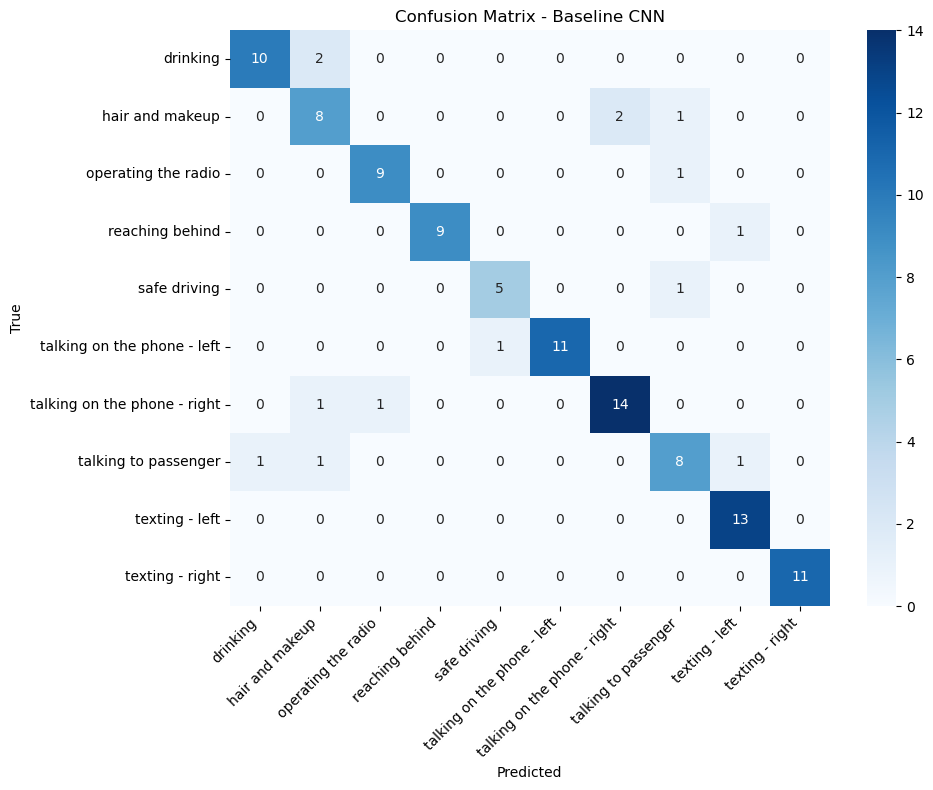

In [9]:
#import numpy as np
#from sklearn.metrics import classification_report, confusion_matrix
# seaborn as sns

y_true = np.concatenate([y for x, y in test_data], axis=0)
y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=train_data.class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_data.class_names,
            yticklabels=train_data.class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Baseline CNN")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Testing the model manually

In [6]:
#from tensorflow.keras.models import load_model
model = load_model(r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\baseline_cnn_driver_distraction.keras")

Prediction vector:
[1.5009020e-08 4.8476757e-04 9.9949622e-01 3.1176165e-07 1.5591360e-07
 8.8403035e-11 6.3899461e-07 1.2813480e-08 3.5062080e-06 1.4401387e-05]

Predicted class: operating the radio
Confidence: 0.9994962

Top 3 predictions:
operating the radio: 0.9995
hair and makeup: 0.0005
texting - right: 0.0000


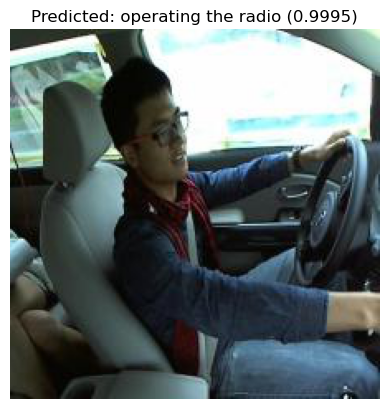

In [32]:
#import numpy as np
#import matplotlib.pyplot as plt
#from tensorflow.keras.preprocessing import image
#from tensorflow.keras.models import load_model

# load trained model
model = load_model(r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\baseline_cnn_driver_distraction.keras")

# class names in the same order as training
class_names = ['drinking', 'hair and makeup', 'operating the radio', 'reaching behind',
               'safe driving', 'talking on the phone - left', 'talking on the phone - right',
               'talking to passenger', 'texting - left', 'texting - right']

# path to one image
img_path = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean\test\operating the radio\img_275_jpg.rf.8f7b40fb130b80d5f6203885187cffdb.jpg"

# load image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

# normalize exactly like training
#img_array = img_array / 255.0

# add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# predict
predictions = model.predict(img_array, verbose=0)[0]

pred_index = np.argmax(predictions)
pred_class = class_names[pred_index]
confidence = predictions[pred_index]

print("Prediction vector:")
print(predictions)

print("\nPredicted class:", pred_class)
print("Confidence:", confidence)

print("\nTop 3 predictions:")
top3 = np.argsort(predictions)[-3:][::-1]
for i in top3:
    print(f"{class_names[i]}: {predictions[i]:.4f}")

plt.imshow(img)
plt.title(f"Predicted: {pred_class} ({confidence:.4f})")
plt.axis("off")
plt.show()

Prediction vector:
[2.7923172e-12 9.1922184e-06 1.6332909e-10 1.8236784e-09 5.1027769e-04
 9.2538111e-03 1.4120897e-09 9.9022663e-01 2.5536020e-08 2.6247144e-13]

Predicted class: talking to passenger
Confidence: 0.9902266

Top 3 predictions:
talking to passenger: 0.9902
talking on the phone - left: 0.0093
safe driving: 0.0005


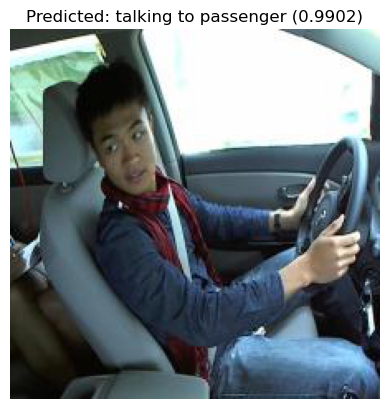

In [34]:
img2_path = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean\test\talking to passenger\img_4597_jpg.rf.92935725d13a59a7f0fc7fa6d621b5ce.jpg"

# load image
img = image.load_img(img2_path, target_size=(224, 224))
img_array = image.img_to_array(img)
# add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# predict
predictions = model.predict(img_array, verbose=0)[0]

pred_index = np.argmax(predictions)
pred_class = class_names[pred_index]
confidence = predictions[pred_index]

print("Prediction vector:")
print(predictions)

print("\nPredicted class:", pred_class)
print("Confidence:", confidence)

print("\nTop 3 predictions:")
top3 = np.argsort(predictions)[-3:][::-1]
for i in top3:
    print(f"{class_names[i]}: {predictions[i]:.4f}")

plt.imshow(img)
plt.title(f"Predicted: {pred_class} ({confidence:.4f})")
plt.axis("off")
plt.show()


Prediction vector:
[8.4079784e-01 9.4606070e-04 4.2228629e-03 2.6416494e-02 3.9717350e-02
 7.9212588e-04 9.7165481e-05 7.3017567e-02 1.3733529e-02 2.5896420e-04]

Predicted class: drinking
Confidence: 0.84079784

Top 3 predictions:
drinking: 0.8408
talking to passenger: 0.0730
safe driving: 0.0397


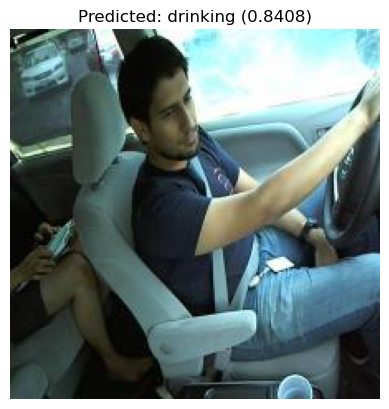

In [35]:
img3_path = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean\test\talking to passenger\img_857_jpg.rf.b4505bb10f665aa3e5bf1666a8e6a5bc.jpg"

# load image
img = image.load_img(img3_path, target_size=(224, 224))
img_array = image.img_to_array(img)
# add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# predict
predictions = model.predict(img_array, verbose=0)[0]

pred_index = np.argmax(predictions)
pred_class = class_names[pred_index]
confidence = predictions[pred_index]

print("Prediction vector:")
print(predictions)

print("\nPredicted class:", pred_class)
print("Confidence:", confidence)

print("\nTop 3 predictions:")
top3 = np.argsort(predictions)[-3:][::-1]
for i in top3:
    print(f"{class_names[i]}: {predictions[i]:.4f}")

plt.imshow(img)
plt.title(f"Predicted: {pred_class} ({confidence:.4f})")
plt.axis("off")
plt.show()

In [ ]:
# Wrong prediction,
# Next Transfer Learning using Resnet50

In [8]:
#import tensorflow as tf
#from tensorflow.keras import layers, models
#from tensorflow.keras.applications import ResNet50
#from tensorflow.keras.applications.resnet50 import preprocess_input
#from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

num_classes = len(train_data.class_names)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

resnet_model = models.Model(inputs, outputs)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │     20,490 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
#training with callbacks

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3
)

history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 426s 7s/step - accuracy: 0.1808 - loss: 2.5328 - val_accuracy: 0.3582 - val_loss: 1.9454 - learning_rate: 0.0010
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 353s 5s/step - accuracy: 0.3344 - loss: 1.9664 - val_accuracy: 0.4179 - val_loss: 1.6528 - learning_rate: 0.0010
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 260s 4s/step - accuracy: 0.4165 - loss: 1.6923 - val_accuracy: 0.5572 - val_loss: 1.4754 - learning_rate: 0.0010
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 720s 12s/step - accuracy: 0.4864 - loss: 1.4754 - val_accuracy: 0.5522 - val_loss: 1.3981 - learning_rate: 0.0010
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 887s 10s/step - accuracy: 0.5141 - loss: 1.4109 - val_accuracy: 0.5224 - val_loss: 1.4223 - learning_rate: 0.0010
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.5541 - loss: 1.2776 - val_accuracy: 0.6070 - val_loss: 1.2002 - learning_rate: 0.0010
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.6064 - loss: 1.1892 - val_a

In [11]:
test_loss, test_acc = resnet_model.evaluate(test_data)
print("ResNet50 Test Accuracy:", test_acc)

resnet_model.save(r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\resnet50_driver_distraction.keras")

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.7321 - loss: 0.8160
ResNet50 Test Accuracy: 0.7321428656578064


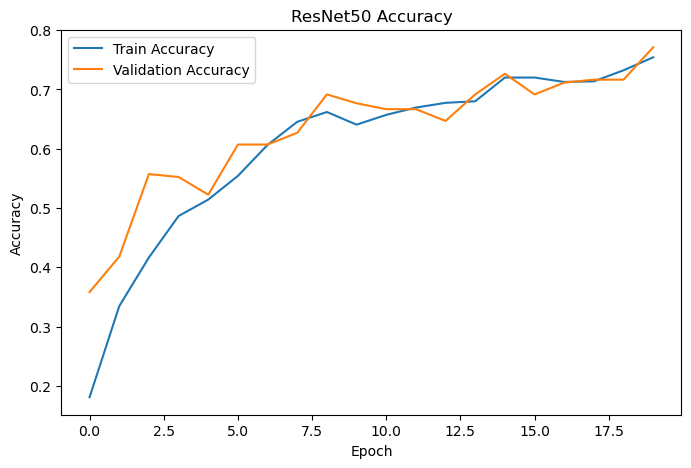

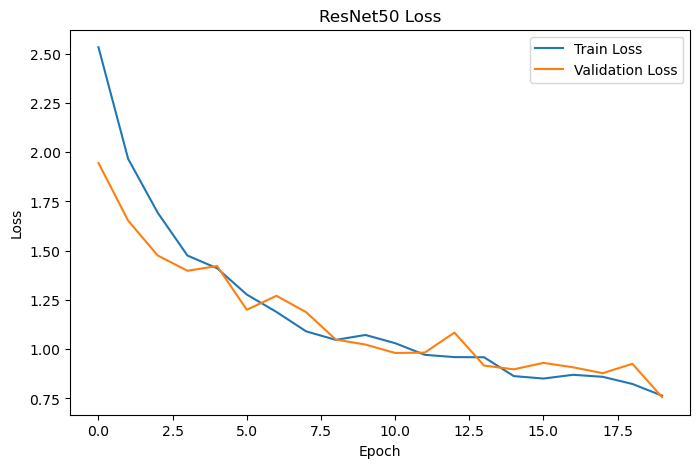

In [12]:
#plot training curves
#import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_resnet.history["accuracy"], label="Train Accuracy")
plt.plot(history_resnet.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("ResNet50 Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_resnet.history["loss"], label="Train Loss")
plt.plot(history_resnet.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("ResNet50 Loss")
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 6s/step
                              precision    recall  f1-score   support

                    drinking       0.67      0.67      0.67        12
             hair and makeup       0.50      0.55      0.52        11
         operating the radio       0.77      1.00      0.87        10
             reaching behind       0.75      0.90      0.82        10
                safe driving       0.50      0.67      0.57         6
 talking on the phone - left       0.62      0.83      0.71        12
talking on the phone - right       1.00      0.81      0.90        16
        talking to passenger       0.75      0.55      0.63        11
              texting - left       0.83      0.77      0.80        13
             texting - right       1.00      0.55      0.71        11

                    accuracy                           0.73       112
                   macro avg       0.74      0.73      0.72       112
                weighted avg       0.76      0.73  

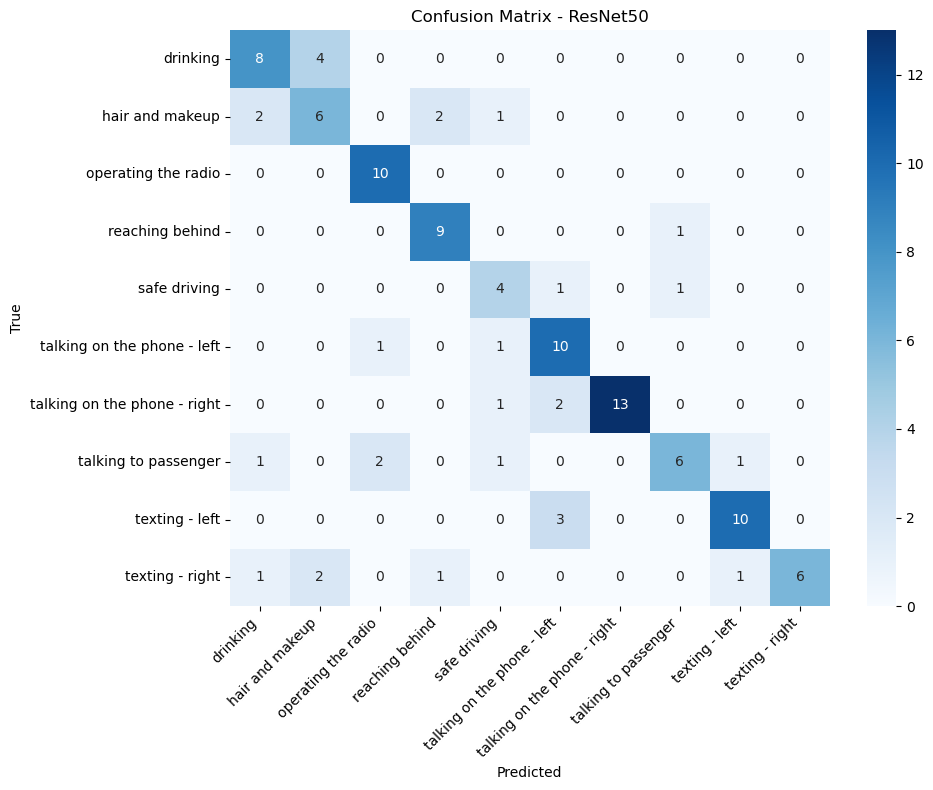

In [13]:
#import numpy as np
#from sklearn.metrics import classification_report, confusion_matrix
#import seaborn as sns

y_true = np.concatenate([y for x, y in test_data], axis=0)
y_pred_probs = resnet_model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=train_data.class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.class_names,
    yticklabels=train_data.class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ResNet50")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
#from tensorflow.keras.models import load_model

resnet_model = load_model(
    r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\resnet50_driver_distraction.keras"
)


Prediction vector:
[0.03246504 0.00542237 0.88108885 0.04844399 0.00678984 0.0117977
 0.0010752  0.00578901 0.0023542  0.0047738 ]

Predicted class: operating the radio
Confidence: 0.88108885

Top 3 predictions:
operating the radio: 0.8811
reaching behind: 0.0484
drinking: 0.0325


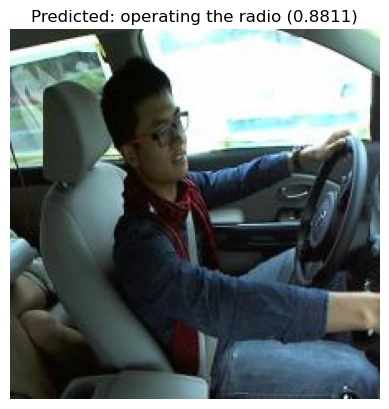

In [35]:
#from tensorflow.keras.preprocessing import image
#import numpy as np
#import matplotlib.pyplot as plt

img_path = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean\test\operating the radio\img_275_jpg.rf.8f7b40fb130b80d5f6203885187cffdb.jpg"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = resnet_model.predict(img_array, verbose=0)[0]

pred_index = np.argmax(predictions)
pred_class = class_names[pred_index]
confidence = predictions[pred_index]

print("Prediction vector:")
print(predictions)

print("\nPredicted class:", pred_class)
print("Confidence:", confidence)

print("\nTop 3 predictions:")
top3 = np.argsort(predictions)[-3:][::-1]
for i in top3:
    print(f"{class_names[i]}: {predictions[i]:.4f}")

plt.imshow(img)
plt.title(f"Predicted: {pred_class} ({confidence:.4f})")
plt.axis("off")
plt.show()

Prediction vector:
[0.0046768  0.0006393  0.2787407  0.08081613 0.01945547 0.09658393
 0.01026784 0.47316182 0.02537313 0.0102849 ]

Predicted class: talking to passenger
Confidence: 0.47316182

Top 3 predictions:
talking to passenger: 0.4732
operating the radio: 0.2787
talking on the phone - left: 0.0966


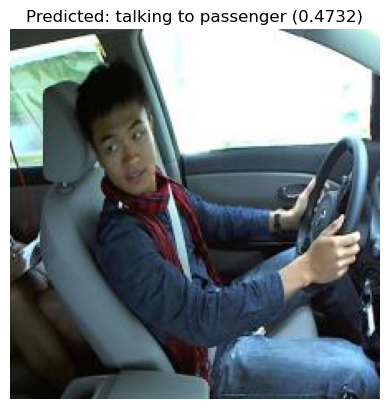

In [36]:
img2_path = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean\test\talking to passenger\img_4597_jpg.rf.92935725d13a59a7f0fc7fa6d621b5ce.jpg"
img = image.load_img(img2_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = resnet_model.predict(img_array, verbose=0)[0]

pred_index = np.argmax(predictions)
pred_class = class_names[pred_index]
confidence = predictions[pred_index]

print("Prediction vector:")
print(predictions)

print("\nPredicted class:", pred_class)
print("Confidence:", confidence)

print("\nTop 3 predictions:")
top3 = np.argsort(predictions)[-3:][::-1]
for i in top3:
    print(f"{class_names[i]}: {predictions[i]:.4f}")

plt.imshow(img)
plt.title(f"Predicted: {pred_class} ({confidence:.4f})")
plt.axis("off")
plt.show()

Prediction vector:
[0.27599913 0.03055931 0.09142843 0.00642565 0.3580748  0.10939338
 0.03923951 0.01643721 0.06359809 0.00884449]

Predicted class: safe driving
Confidence: 0.3580748

Top 3 predictions:
safe driving: 0.3581
drinking: 0.2760
talking on the phone - left: 0.1094


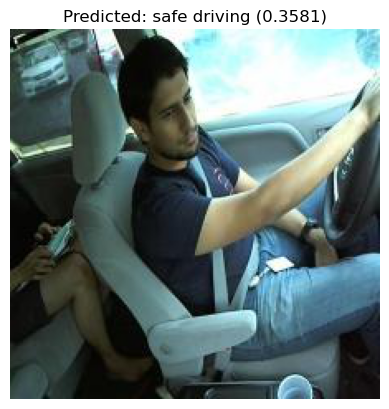

In [37]:
img3_path = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean\test\talking to passenger\img_857_jpg.rf.b4505bb10f665aa3e5bf1666a8e6a5bc.jpg"
img = image.load_img(img3_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = resnet_model.predict(img_array, verbose=0)[0]

pred_index = np.argmax(predictions)
pred_class = class_names[pred_index]
confidence = predictions[pred_index]

print("Prediction vector:")
print(predictions)

print("\nPredicted class:", pred_class)
print("Confidence:", confidence)

print("\nTop 3 predictions:")
top3 = np.argsort(predictions)[-3:][::-1]
for i in top3:
    print(f"{class_names[i]}: {predictions[i]:.4f}")

plt.imshow(img)
plt.title(f"Predicted: {pred_class} ({confidence:.4f})")
plt.axis("off")
plt.show()

In [15]:
# fine tuning

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_resnet_ft = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 383s 6s/step - accuracy: 0.6181 - loss: 1.1809 - val_accuracy: 0.7463 - val_loss: 0.8243 - learning_rate: 1.0000e-05
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 394s 7s/step - accuracy: 0.7221 - loss: 0.8365 - val_accuracy: 0.7313 - val_loss: 0.8325 - learning_rate: 1.0000e-05
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 544s 9s/step - accuracy: 0.7733 - loss: 0.6861 - val_accuracy: 0.7413 - val_loss: 0.7617 - learning_rate: 1.0000e-05
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 477s 8s/step - accuracy: 0.8027 - loss: 0.6127 - val_accuracy: 0.7761 - val_loss: 0.7134 - learning_rate: 3.0000e-06
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.8112 - loss: 0.5682 - val_accuracy: 0.7811 - val_loss: 0.6869 - learning_rate: 3.0000e-06
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.8251 - loss: 0.5554 - val_accuracy: 0.7811 - val_loss: 0.6722 - learning_rate: 3.0000e-06
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.8357 

In [16]:
test_loss, test_acc = resnet_model.evaluate(test_data)
print("Fine-tuned ResNet50 Test Accuracy:", test_acc)
resnet_model.save(r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\resnet50_finetuned_driver_distraction.keras")

4/4 ━━━━━━━━━━━━━━━━━━━━ 40s 9s/step - accuracy: 0.8214 - loss: 0.5910
Fine-tuned ResNet50 Test Accuracy: 0.8214285969734192


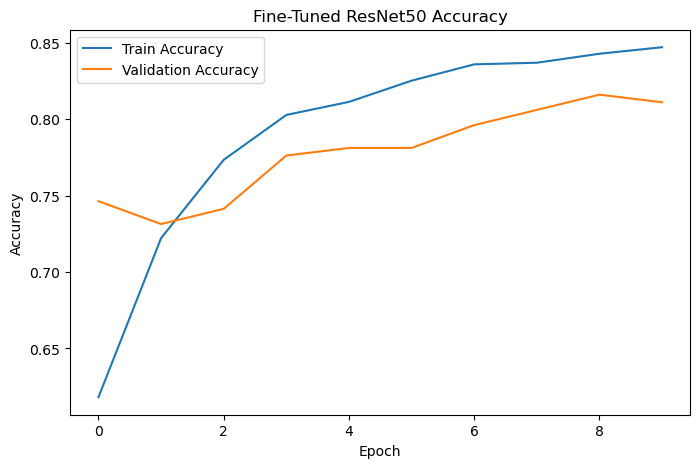

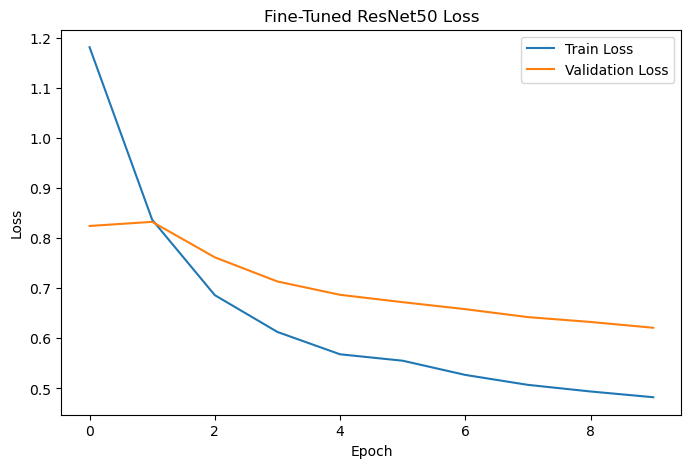

In [17]:
#fine tuning accuracy and loss
#import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_resnet_ft.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet_ft.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Fine-Tuned ResNet50 Accuracy')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_resnet_ft.history['loss'], label='Train Loss')
plt.plot(history_resnet_ft.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Fine-Tuned ResNet50 Loss')
plt.show()

In [18]:
#import numpy as np
#from sklearn.metrics import classification_report, confusion_matrix

y_true = np.concatenate([y for x, y in test_data], axis=0)
y_pred_probs = resnet_model.predict(test_data, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=train_data.class_names))

                              precision    recall  f1-score   support

                    drinking       1.00      0.67      0.80        12
             hair and makeup       0.69      0.82      0.75        11
         operating the radio       1.00      1.00      1.00        10
             reaching behind       0.75      0.90      0.82        10
                safe driving       0.55      1.00      0.71         6
 talking on the phone - left       0.65      0.92      0.76        12
talking on the phone - right       0.93      0.88      0.90        16
        talking to passenger       0.86      0.55      0.67        11
              texting - left       1.00      0.69      0.82        13
             texting - right       1.00      0.91      0.95        11

                    accuracy                           0.82       112
                   macro avg       0.84      0.83      0.82       112
                weighted avg       0.86      0.82      0.82       112



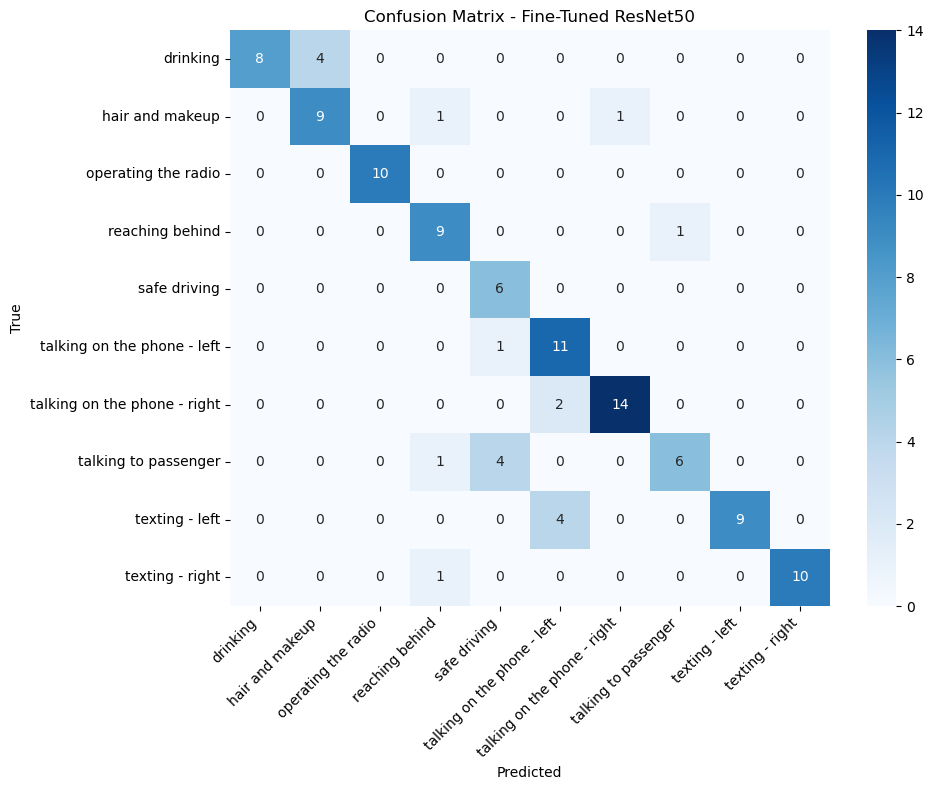

In [19]:
#import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_data.class_names,
    yticklabels=train_data.class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Fine-Tuned ResNet50")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
#from tensorflow.keras.models import load_model

resnet_ft_model = load_model(
    r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\resnet50_finetuned_driver_distraction.keras"
)

Prediction vector:
[1.5497197e-02 2.4424419e-03 7.7797180e-01 1.3390253e-01 2.8072095e-03
 9.2560789e-03 5.8618602e-06 3.5960540e-02 4.8962198e-03 1.7260065e-02]

Predicted class: operating the radio
Confidence: 0.7779718

Top 3 predictions:
operating the radio: 0.7780
reaching behind: 0.1339
talking to passenger: 0.0360


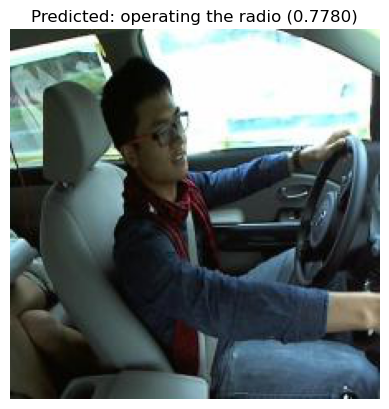

In [31]:
#from tensorflow.keras.preprocessing import image
#import numpy as np
#import matplotlib.pyplot as plt

img_path = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean\test\operating the radio\img_275_jpg.rf.8f7b40fb130b80d5f6203885187cffdb.jpg"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = resnet_ft_model.predict(img_array, verbose=0)[0]

pred_index = np.argmax(predictions)
pred_class = class_names[pred_index]
confidence = predictions[pred_index]

print("Prediction vector:")
print(predictions)

print("\nPredicted class:", pred_class)
print("Confidence:", confidence)

print("\nTop 3 predictions:")
top3 = np.argsort(predictions)[-3:][::-1]
for i in top3:
    print(f"{class_names[i]}: {predictions[i]:.4f}")

plt.imshow(img)
plt.title(f"Predicted: {pred_class} ({confidence:.4f})")
plt.axis("off")
plt.show()

Prediction vector:
[2.1399457e-03 1.0315380e-03 6.6752888e-02 1.9064511e-01 9.5544800e-02
 9.4978698e-02 1.4457526e-04 5.2880591e-01 1.4666641e-02 5.2898545e-03]

Predicted class: talking to passenger
Confidence: 0.5288059

Top 3 predictions:
talking to passenger: 0.5288
reaching behind: 0.1906
safe driving: 0.0955


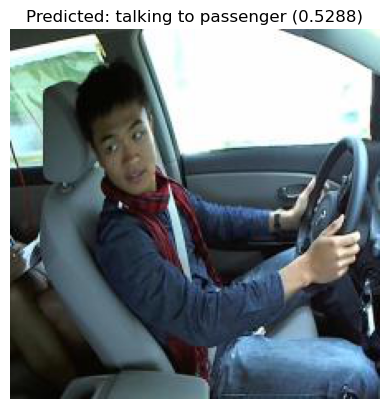

In [32]:


img2_path = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean\test\talking to passenger\img_4597_jpg.rf.92935725d13a59a7f0fc7fa6d621b5ce.jpg"

img = image.load_img(img2_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = resnet_ft_model.predict(img_array, verbose=0)[0]

pred_index = np.argmax(predictions)
pred_class = class_names[pred_index]
confidence = predictions[pred_index]

print("Prediction vector:")
print(predictions)

print("\nPredicted class:", pred_class)
print("Confidence:", confidence)

print("\nTop 3 predictions:")
top3 = np.argsort(predictions)[-3:][::-1]
for i in top3:
    print(f"{class_names[i]}: {predictions[i]:.4f}")

plt.imshow(img)
plt.title(f"Predicted: {pred_class} ({confidence:.4f})")
plt.axis("off")
plt.show()

Prediction vector:
[3.4920264e-02 1.0094717e-02 9.8972075e-02 8.9539299e-03 7.8320205e-01
 3.4810320e-02 1.8206223e-04 1.4430237e-02 1.1176503e-02 3.2577245e-03]

Predicted class: safe driving
Confidence: 0.78320205

Top 3 predictions:
safe driving: 0.7832
operating the radio: 0.0990
drinking: 0.0349


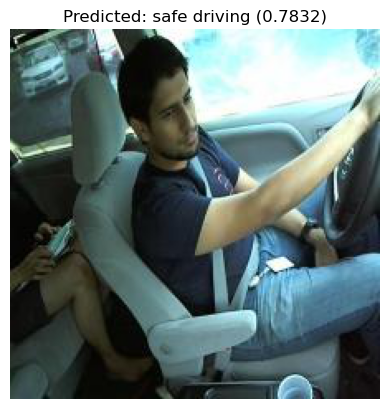

In [33]:


img3_path = r"C:\Users\asimm\OneDrive\Documents\PSU\2026 sem01\test\driver_dataset_clean\test\talking to passenger\img_857_jpg.rf.b4505bb10f665aa3e5bf1666a8e6a5bc.jpg"

img = image.load_img(img3_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = resnet_ft_model.predict(img_array, verbose=0)[0]

pred_index = np.argmax(predictions)
pred_class = class_names[pred_index]
confidence = predictions[pred_index]

print("Prediction vector:")
print(predictions)

print("\nPredicted class:", pred_class)
print("Confidence:", confidence)

print("\nTop 3 predictions:")
top3 = np.argsort(predictions)[-3:][::-1]
for i in top3:
    print(f"{class_names[i]}: {predictions[i]:.4f}")

plt.imshow(img)
plt.title(f"Predicted: {pred_class} ({confidence:.4f})")
plt.axis("off")
plt.show()